**Table of contents**<a id='toc0_'></a>    
- [Part One: Load, inspect, and subset the dataset into features relevant to the research question.](#toc1_1_)    
    - [Load and inspect the initial dataset's distribution and columns:](#toc1_1_1_)    
    - [Subset the dataset to columns of interest before data cleaning](#toc1_1_2_)    
- [Part Two: Data Cleaning and Exploratory Data Analysis](#toc1_1_3_)    
    - [Inspect the distribution of the subsetted dataset](#toc1_1_4_)    
    - [Boxplots of the numeric variables to further investigate distribution](#toc1_1_5_)    
    - [Look for outliers in the numeric variables in the dataset](#toc1_1_6_)    
    - [Handle missing values in the dataset](#toc1_1_7_)    
    - [Heatmap of the numeric features to look for multicollinearity](#toc1_1_8_)    
- [Part Three: Preprocessing and Feature Engineering (encoding, standardization, adjusting features)](#toc1_2_)    
    - [Create a new variable for "time since first sexual intercourse"](#toc1_2_1_)    
    - [Evaluate heatmap again to confirm changes in multicollinearity](#toc1_2_2_)    
    - [Split the data](#toc1_2_3_)    
    - [Standardization](#toc1_2_4_)    
- [Part Four: Modeling](#toc1_3_)    
    - [Model 1: Logistic Regression](#toc1_3_1_)    
    - [Model 2: KNN](#toc1_3_2_)    
    - [Model 3: Naive Bayes](#toc1_3_3_)    
- [Part Five: Feature Importance](#toc1_4_)    
    - [Create a feature importance chart](#toc1_4_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import math
from matplotlib.colors import ListedColormap
from sklearn.metrics import log_loss

## <a id='toc1_1_'></a>[Part One: Load, inspect, and subset the dataset into features relevant to the research question.](#toc0_)

### <a id='toc1_1_1_'></a>[Load and inspect the initial dataset's distribution and columns:](#toc0_)

In [2]:
# Import the dataset
df = pd.read_csv("C:\\Users\\Ibrou\\OneDrive\\Freshman UNCC\\2301\\cervical-cancer.csv")
df = pd.DataFrame(df)

In [3]:
# Size of the dataset
df.shape

(858, 36)

In [4]:
# Look at the first rows of the data
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
# List all column names in the dataset
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [6]:
# Distribution of numerical columns of the dataset
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,845.000000,750.000000,750.000000,741.000000,...,71.000000,71.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,...,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,...,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Look at info on the dataset like data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [8]:
# Look for duplicates within the entire dataset- treat these as errors and remove them
df.duplicated().sum() 

np.int64(23)

In [9]:
# Drop the second of each set of duplicate rows
df.drop_duplicates(inplace=True, keep="first")

### <a id='toc1_1_2_'></a>[Subset the dataset to columns of interest before data cleaning](#toc0_)

In [10]:
# Columns being considered for  research, including the target variable "Dx:Cancer"
df2 = df[["Age", "Number of sexual partners", "First sexual intercourse", "Num of pregnancies", "Smokes (packs/year)", "Hormonal Contraceptives (years)", "IUD (years)", "STDs (number)", "STDs: Time since first diagnosis", "STDs: Time since last diagnosis", "Dx:Cancer", "Dx:CIN", "Dx:HPV"]]

### <a id='toc1_1_3_'></a>[Part Two: Data Cleaning and Exploratory Data Analysis](#toc0_)

### <a id='toc1_1_4_'></a>[Inspect the distribution of the subsetted dataset](#toc0_)

In [11]:
df2.shape

(835, 13)

In [12]:
# Look at the first rows of the subsetted dataset
df2.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,NaN,NaN,0,0,0
3,52,5.0,16.0,4.0,37.0,3.0,0.0,0.0,NaN,NaN,1,0,1
4,46,3.0,21.0,4.0,0.0,15.0,0.0,0.0,NaN,NaN,0,0,0


In [13]:
# Check for missing values for columns of interest which will be addressed later
# Note: 'STDs: Time since first diagnosis' and 'STDs: Time since last diagnosis' have many missing values and will be dropped since they contain little information.
df2.isna().sum()

Age                                   0
Number of sexual partners            25
First sexual intercourse              7
Num of pregnancies                   56
Smokes (packs/year)                  13
Hormonal Contraceptives (years)     103
IUD (years)                         112
STDs (number)                       100
STDs: Time since first diagnosis    764
STDs: Time since last diagnosis     764
Dx:Cancer                             0
Dx:CIN                                0
Dx:HPV                                0
dtype: int64

In [14]:
# Distribution of numerical columns of the new dataset
# Note: "First sexual intercourse," which has null values, has a median above the minimum "Age" in the dataset and cannot be used for imputation.
# Note: The diagnosis variables are actually categorical variables, but they have already been encoded.
df2.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV
count,835.000000,810.000000,828.000000,779.000000,822.000000,732.000000,723.000000,735.000000,71.000000,71.000000,835.000000,835.000000,835.000000
mean,27.023952,2.551852,17.020531,2.304236,0.465823,2.302916,0.527621,0.180952,6.140845,5.816901,0.021557,0.010778,0.021557
std,8.482986,1.676686,2.817000,1.455817,2.256273,3.794180,1.965439,0.568153,5.895024,5.755271,0.145319,0.103320,0.145319
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,26.000000,2.000000,17.000000,2.000000,0.000000,0.500000,0.000000,0.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,3.000000,0.000000,0.000000,8.000000,7.500000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,37.000000,30.000000,19.000000,4.000000,22.000000,22.000000,1.000000,1.000000,1.000000


In [15]:
# Look at the distribution of the target variable "Dx:Cancer," it has a class imbalance which will be addressed in the modeling phase.
df2["Dx:Cancer"].value_counts()

Dx:Cancer
0    817
1     18
Name: count, dtype: int64

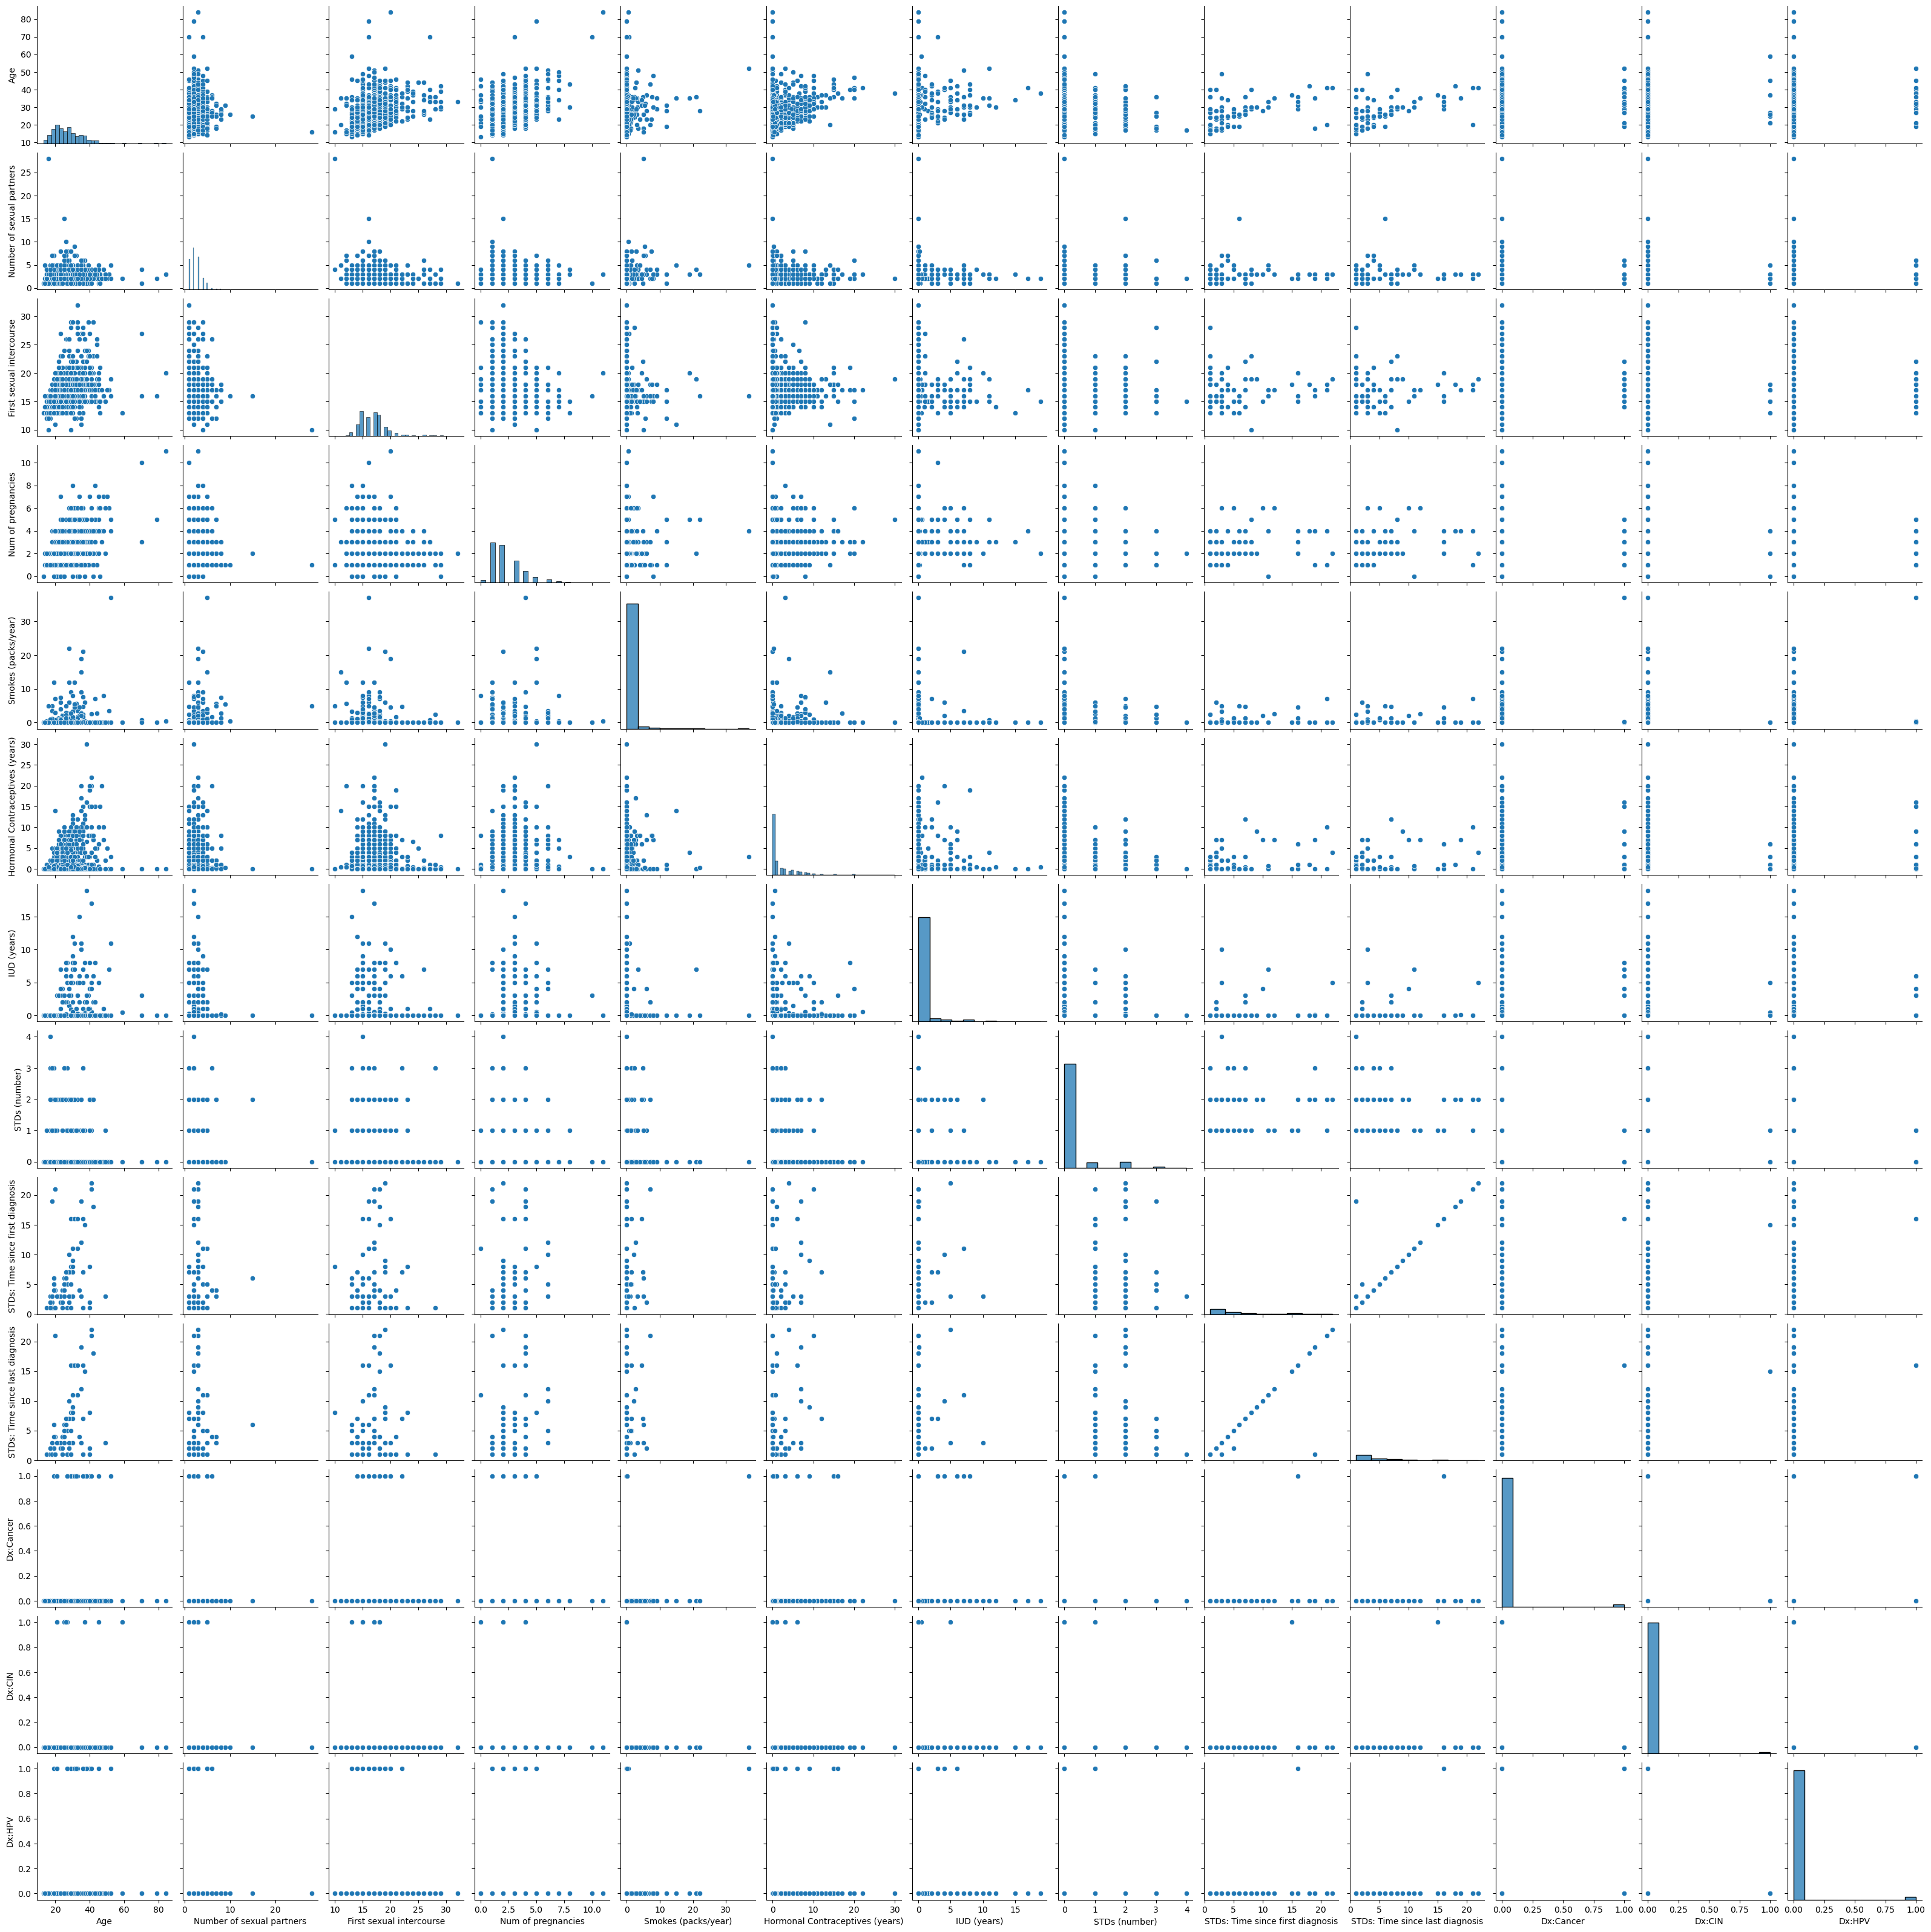

In [16]:
# Distribution of the numeric variables (scatterplots and histograms) shown in a pairplot
sns.pairplot(df2)
plt.show()

### <a id='toc1_1_5_'></a>[Boxplots of the numeric variables to further investigate distribution](#toc0_)

<Axes: >

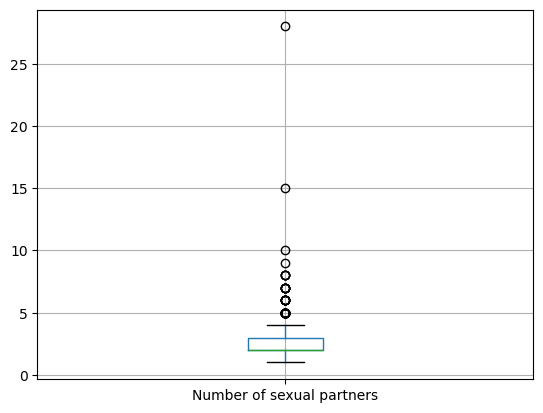

In [17]:
df2.boxplot(column = 'Number of sexual partners')

<Axes: >

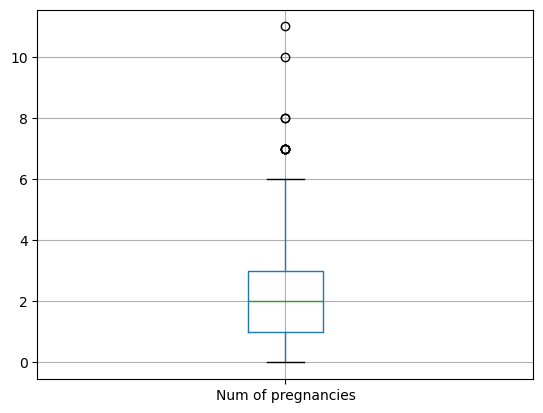

In [18]:
df2.boxplot(column = 'Num of pregnancies')

<Axes: >

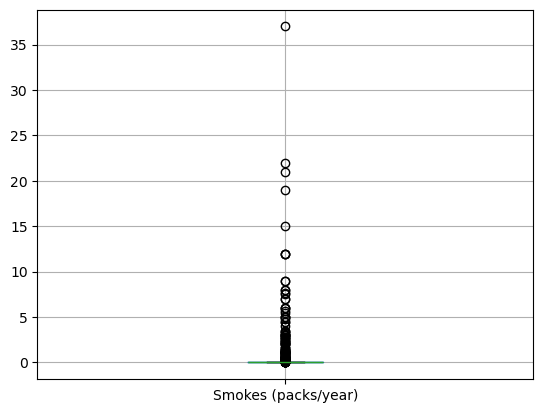

In [19]:
df2.boxplot(column = 'Smokes (packs/year)')

<Axes: >

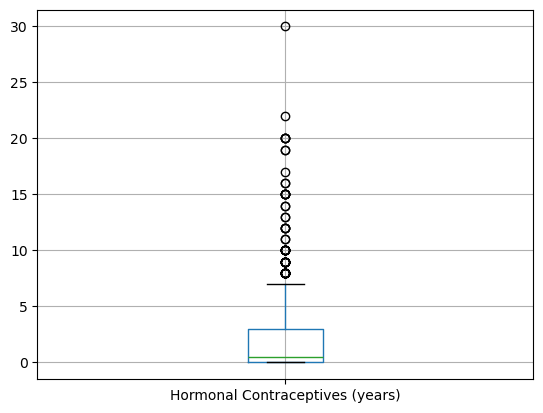

In [20]:
df2.boxplot(column = 'Hormonal Contraceptives (years)')

<Axes: >

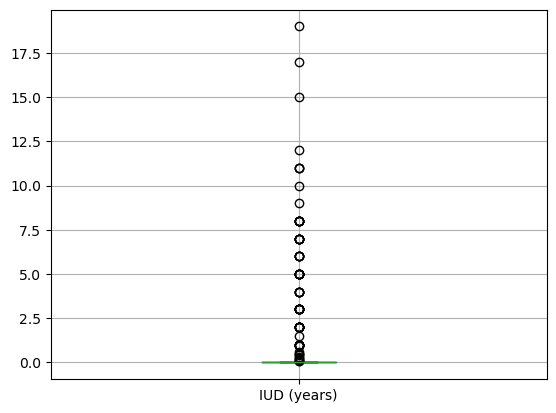

In [21]:
df2.boxplot(column = 'IUD (years)')

<Axes: >

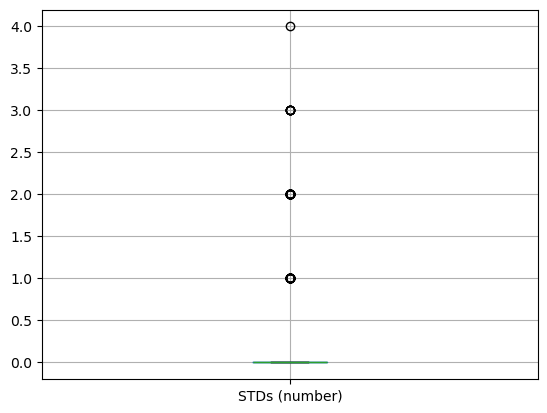

In [22]:
df2.boxplot(column = 'STDs (number)')

<Axes: >

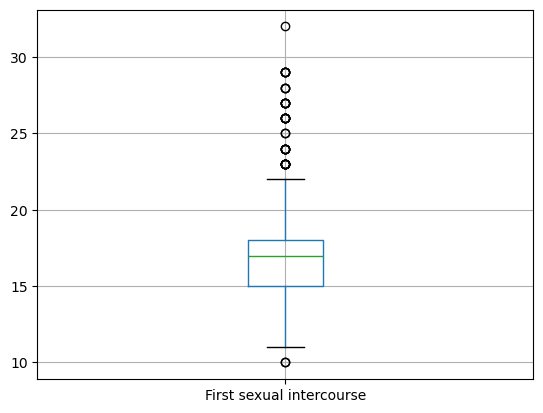

In [25]:
df2.boxplot(column='First sexual intercourse')

<Axes: >

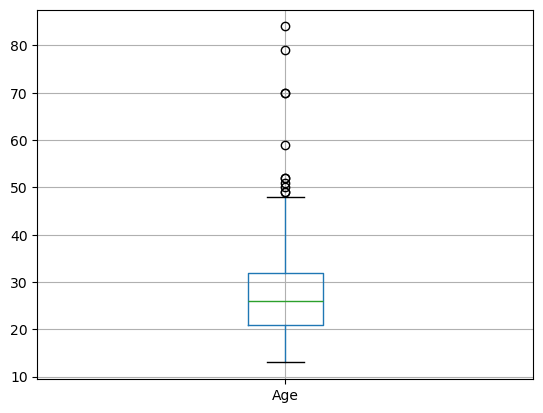

In [27]:
df2.boxplot(column = 'Age')

### <a id='toc1_1_6_'></a>[Look for outliers in the numeric variables in the dataset](#toc0_)

In [28]:
# Define function to find and print outliers and the number of outliers in a column
def outliers(col_name, data):
    q1 = data[col_name].quantile(0.25) # Calculate the first quartile
    q3 = data[col_name].quantile(0.75) # Calculate the third quartile
    iqr = q3 - q1 # Calculate the IQR
    lower_bound = q1 - (1.5*iqr) # Find the lower bound for outliers
    upper_bound = q3 + (1.5*iqr) # Find the upper bound for outliers

    outliers = np.where((data[col_name] < lower_bound) | (data[col_name] > upper_bound)) # Identify outliers
    count = 0
    for i in outliers[0]: # Calculate the total number of outliers
        count += 1
    print("Number of outliers in", col_name, ": ", count) # Display the total number of outliers and what they are
    print("Outliers: ", data[col_name].iloc[outliers[0]])

In [29]:
# Call function for all numeric columns by iterating through them- ignore the outliers for the diagnosis variables since they are actually categorical variables
for c in df2.select_dtypes(include=["int64", "float64"]).columns:
        outliers(c, df2) 

Number of outliers in Age :  11
Outliers:  3      52
6      51
652    59
667    79
668    84
671    52
676    70
679    50
680    49
682    70
685    49
Name: Age, dtype: int64
Number of outliers in Number of sexual partners :  68
Outliers:  3      5.0
26     5.0
29     6.0
52     5.0
56     5.0
      ... 
796    7.0
804    8.0
812    5.0
837    9.0
844    8.0
Name: Number of sexual partners, Length: 68, dtype: float64
Number of outliers in First sexual intercourse :  41
Outliers:  5      23.0
7      26.0
10     26.0
13     25.0
19     27.0
26     23.0
28     24.0
29     26.0
38     24.0
69     23.0
75     27.0
80     27.0
89     32.0
93     29.0
113    23.0
128    29.0
138    28.0
147    10.0
162    23.0
211    26.0
215    24.0
242    23.0
312    27.0
467    10.0
479    24.0
487    26.0
492    26.0
500    29.0
560    24.0
563    28.0
569    25.0
585    28.0
607    29.0
614    23.0
676    27.0
681    29.0
705    23.0
777    26.0
824    27.0
831    23.0
856    24.0
Name: First sexual in

### <a id='toc1_1_7_'></a>[Handle missing values in the dataset](#toc0_)

In [30]:
# Drop the two columns 'STDs: Time since first diagnosis' and 'STDs: Time since last diagnosis' since they have many missing values and contain little information.
df2 = df[["Age", "Number of sexual partners", "First sexual intercourse", "Num of pregnancies", "Smokes (packs/year)", "Hormonal Contraceptives (years)", "IUD (years)", "STDs (number)", "Dx:Cancer", "Dx:CIN", "Dx:HPV"]]

In [31]:
# Fill the missing values in the columns of interest with the median of each column since the median is less affected by outliers and the data is skewed. 
# The column "First sexual intercourse" cannot be used for imputation since its median is above the minimum "Age" in the dataset.
df2["Number of sexual partners"].fillna(df2["Number of sexual partners"].median(), inplace=True)
df2["Num of pregnancies"].fillna(df2["Num of pregnancies"].median(), inplace=True)
df2["Smokes (packs/year)"].fillna(df2["Smokes (packs/year)"].median(), inplace=True)
df2["Hormonal Contraceptives (years)"].fillna(df2["Hormonal Contraceptives (years)"].median(), inplace=True)
df2["IUD (years)"].fillna(df2["IUD (years)"].median(), inplace=True)
df2["STDs (number)"].fillna(df2["STDs (number)"].median(), inplace=True)

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_61992\3298997027.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Number of sexual partners"].fillna(df2["Number of sexual partners"].median(), inplace=True)
C:\Users\Ibrou\AppData\Local\Temp\ipykernel_61992\3298997027.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Number of sexual 

In [32]:
# Drop the rows with missing values in the column "First sexual intercourse" since it cannot be used for imputation and there are few missing values.
df2.dropna(subset=["First sexual intercourse"], inplace=True)

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_61992\1938107940.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.dropna(subset=["First sexual intercourse"], inplace=True)


In [33]:
# Confirm all the missing values have been dropped or filled
df2.isna().sum()

Age                                0
Number of sexual partners          0
First sexual intercourse           0
Num of pregnancies                 0
Smokes (packs/year)                0
Hormonal Contraceptives (years)    0
IUD (years)                        0
STDs (number)                      0
Dx:Cancer                          0
Dx:CIN                             0
Dx:HPV                             0
dtype: int64

### <a id='toc1_1_8_'></a>[Heatmap of the numeric features to look for multicollinearity](#toc0_)

In [34]:
colors = sns.color_palette("blend:#003B46,#00A3A9", 25)

<Axes: >

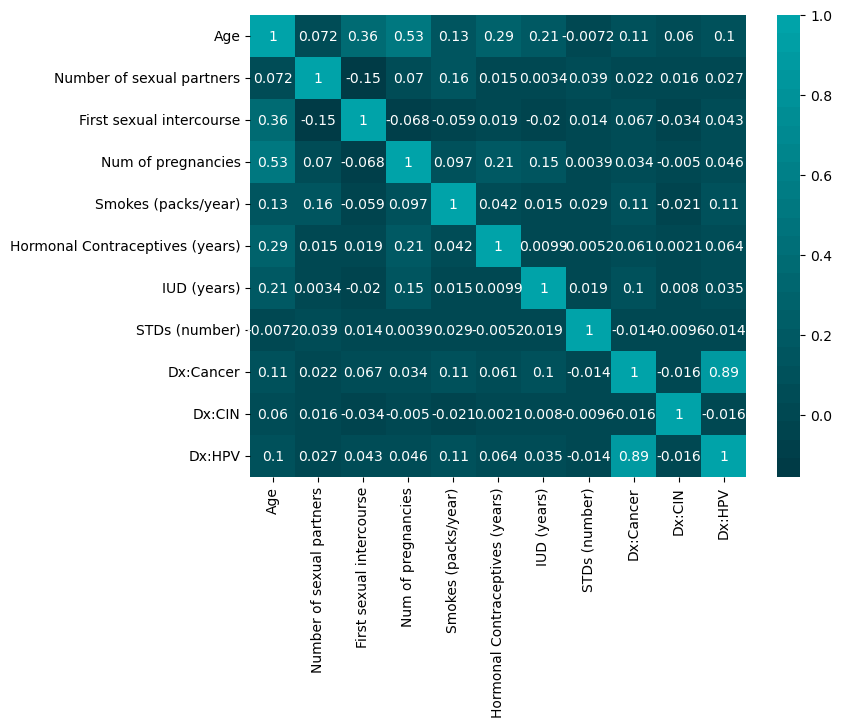

In [35]:
# Heatmap of the numeric variables (correlation matrix) showing their correlation coefficients
# Note: there is high correlation between some of the features, like "Age" with "Num of pregnancies"
plt.figure(figsize = (8, 6))
sns.heatmap(df2.corr(), annot=True, cmap=colors) # Display the correlation coefficients to two decimal places

## <a id='toc1_2_'></a>[Part Three: Preprocessing and Feature Engineering (encoding, standardization, adjusting features)](#toc0_)

### <a id='toc1_2_1_'></a>[Create a new variable for "time since first sexual intercourse"](#toc0_)

In [36]:
# 'Age' is highly correlated with other variables, so create a new variable with the time since first sexual intercourse to limit multicollinearity
# Subtract the "First sexual intercourse" column from the "Age" column
df2["Time since first sexual intercourse"] = df2["Age"]-df2["First sexual intercourse"]

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_61992\539906752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Time since first sexual intercourse"] = df2["Age"]-df2["First sexual intercourse"]


In [37]:
# Drop the columns used to create the new variable "Time since first sexual intercourse" to limit multicollinearity
df2.drop(columns=["First sexual intercourse", "Age"], inplace=True)

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_61992\3787684228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(columns=["First sexual intercourse", "Age"], inplace=True)


### <a id='toc1_2_2_'></a>[Evaluate heatmap again to confirm changes in multicollinearity](#toc0_)

<Axes: >

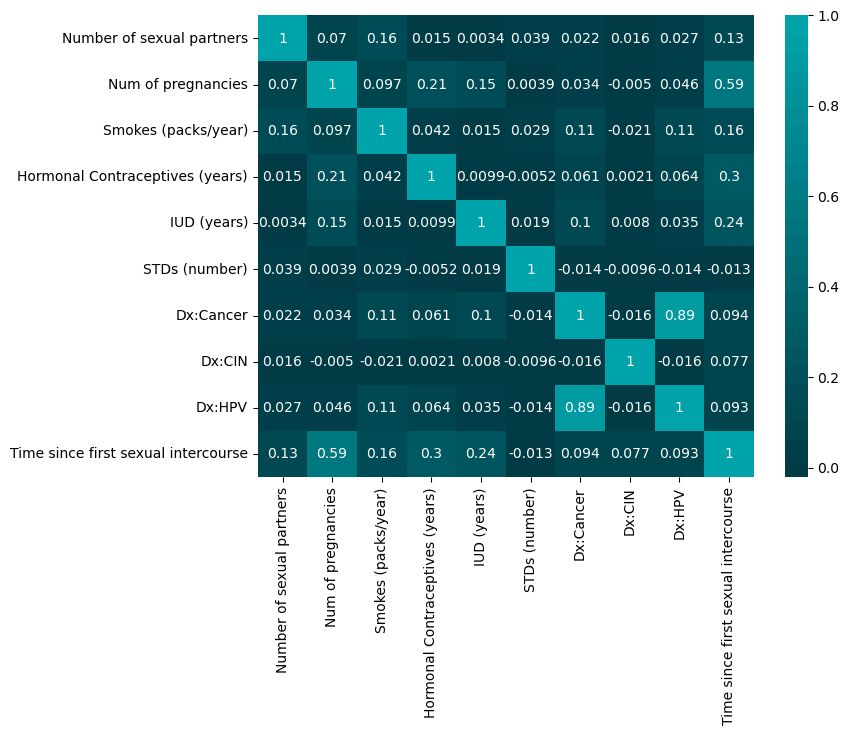

In [38]:
# Evaluate the heatmap again to confirm the correlation between the variables has decreased
# Note: It has decreased but there is still some correlation between features
plt.figure(figsize = (8, 6))
sns.heatmap(df2.corr(), annot=True, cmap=colors) # Display the correlation coefficients to two decimal places

In [90]:
df2["Dx:Cancer"].value_counts() # Look at the distribution of the target variable "Dx:Cancer," it has a class imbalance which will be addressed in the modeling phase.

Dx:Cancer
0    810
1     18
Name: count, dtype: int64

### <a id='toc1_2_3_'></a>[Split the data](#toc0_)

Split the data into x and y, training and testing sets

In [146]:
# Split the data into x and y
X = df2.drop(columns=["Dx:Cancer"])
y = df2["Dx:Cancer"]

In [195]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42) # The data is stratified to maintain the same class distribution 
                                                                                                         # in the training and testing sets as in the original dataset

### <a id='toc1_2_4_'></a>[Standardization](#toc0_)

Standardize/normalize the training and testing sets- separately to avoid data leakage
- Standardize the numeric features

In [196]:
scaler = StandardScaler() # Initialize the scaler
# Standardize the numeric columns in the training and testing X sets separately to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## <a id='toc1_3_'></a>[Part Four: Modeling](#toc0_)

### <a id='toc1_3_1_'></a>[Model 1: Logistic Regression](#toc0_)

In [197]:
model1 = LogisticRegression() # Initialize the model
model1.fit(X_train_scaled, y_train) # Fit the model to the training data

LogisticRegression()

Display a confusion matrix for Model 1's performance

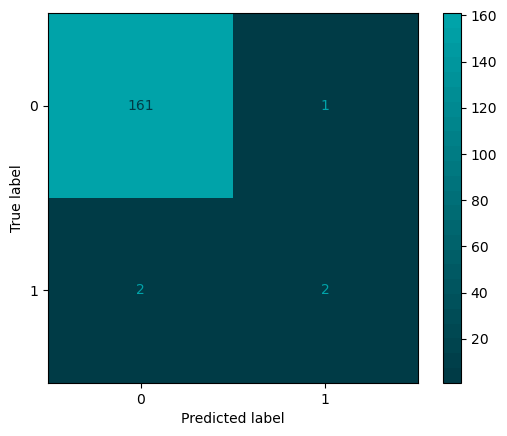

In [198]:
confusion_matrix = metrics.confusion_matrix(y_test, model1.predict(X_test_scaled)) # Create the confusion matrix with predictions
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0,1]) # Adjust the confusion matrix with labels

cm_display.plot(cmap = ListedColormap(colors)) # Show the confusion matrix
plt.show()

In [199]:
model1recall = metrics.recall_score(y_test, model1.predict(X_test_scaled)) # Calculate the recall of Model 1 with its predictions on the testing data
print(model1recall)

0.5


In [200]:
y1probs = model1.predict_proba(X_test_scaled)[:, 1] # Get the predicted probabilities
loss = log_loss(y_test, y1probs) # Calculate the log loss of Model 1 with its predicted probabilities on the testing data

print(f"Log Loss: {loss:.4f}") # Display log loss to four decimal places

Log Loss: 0.0280


### <a id='toc1_3_2_'></a>[Model 2: KNN](#toc0_)

In [201]:
knn_cv = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": np.arange(1, 30, 2)}, cv=5) # Initialize the cross-validation for KNN with a range of 1-30 (every other number)
knn_cv.fit(X_train_scaled, y_train) # Fit the cross-validation
model2 = KNeighborsClassifier(n_neighbors=knn_cv.best_params_['n_neighbors']) # Initialize the model with the optimal number of neighbors from the cross-validation
model2.fit(X_train_scaled, y_train) # Fit the model

KNeighborsClassifier(n_neighbors=np.int64(1))

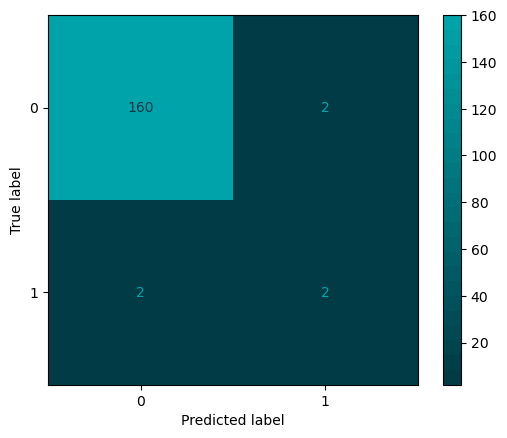

In [202]:
confusion_matrix = metrics.confusion_matrix(y_test, model2.predict(X_test_scaled)) # Create the confusion matrix with predictions
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0,1]) # Adjust the confusion matrix with labels

cm_display.plot(cmap = ListedColormap(colors)) # Show the confusion matrix
plt.show()

In [203]:
model2recall = metrics.recall_score(y_test, model2.predict(X_test_scaled)) # Calculate the recall of Model 2 with its predictions on the testing data
print(model2recall) # Print the recall of Model 2

0.5


In [204]:
y2probs = model2.predict_proba(X_test_scaled)[:, 1] # Get the predicted probabilities 
loss = log_loss(y_test, y2probs) # Calculate the log loss of Model 2 with its predicted probabilities on the testing data

print(f"Log Loss: {loss:.4f}") # Display log loss to four decimal places

Log Loss: 0.8685


### <a id='toc1_3_3_'></a>[Model 3: Naive Bayes](#toc0_)

In [205]:
model3 = GaussianNB() # Initialize the model
model3.fit(X_train_scaled, y_train) # Fit the model

y3_pred = model3.predict(X_test_scaled) # Make predictions with Model 3

c:\Users\Ibrou\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


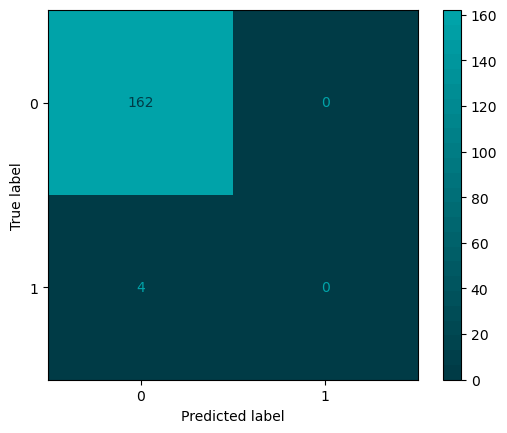

In [206]:
confusion_matrix = metrics.confusion_matrix(y_test, model3.predict(X_test)) # Create the confusion matrix with predictions
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0,1]) # Adjust the confusion matrix with labels

cm_display.plot(cmap = ListedColormap(colors)) # Show the confusion matrix
plt.show()

In [207]:
model3recall = metrics.recall_score(y_test, model3.predict(X_test)) # Calculate the recall of Model 3 with its predictions on the testing data
print(model3recall) # Print the recall of Model 3

0.0


c:\Users\Ibrou\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


In [208]:
y3probs = model3.predict_proba(X_test_scaled)[:, 1] # Get the predicted probabilities
loss = log_loss(y_test, y3probs) # Calculate the log loss of Model 3 with its predicted probabilities on the testing data

print(f"Log Loss: {loss:.4f}") # Display log loss to four decimal places

Log Loss: 0.8685


## <a id='toc1_4_'></a>[Part Five: Feature Importance](#toc0_)

### <a id='toc1_4_1_'></a>[Create a feature importance chart](#toc0_)

In [209]:
features = model1.coef_.flatten()

for i in range(len(features)): # Iterate through the coefficients and exponentiate them to better interpret the values
    features[i-1] = math.exp(features[i-1])
feature_importance = pd.DataFrame(
    {
        "Feature": list(X_train.columns), # Name the features using the column names of the training data
        "Weight": features,
        "Absolute_Weight": abs(1-features), # The further a value is from 1, the larger its impact
    }
)

feature_importance = feature_importance.sort_values(by = "Absolute_Weight", ascending=False) # Sort the features by their absolute weight in descending order

Text(0.5, 1.0, 'Feature Importance')

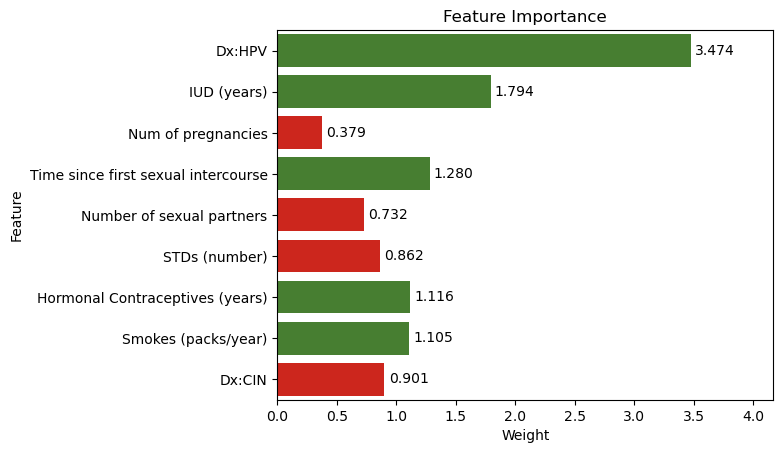

In [210]:
# Assign colors, red for negative impact (< 1) and green for positive impact (> 1)
color = ["#418b24" if x > 1 else "#E90c00" for x in feature_importance["Weight"]]

# create Bar Plot
ax = sns.barplot(
    data=feature_importance,
    x="Weight",
    y="Feature",
    palette=color,
    hue="Feature",
    legend=False,
)

# Show weights in bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.3f")

ax.margins(x=0.2)
plt.title("Feature Importance")